## Adatok betöltése

In [2389]:
import pandas as pd

In [2390]:
train = pd.read_csv('./titanic/train.csv')
test = pd.read_csv('./titanic/test.csv')

In [2391]:
print(train.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [2392]:
print(train.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


## Hiányzó és kiugró értékek kezelése

In [2393]:
import seaborn as sb
import matplotlib.pyplot as plt

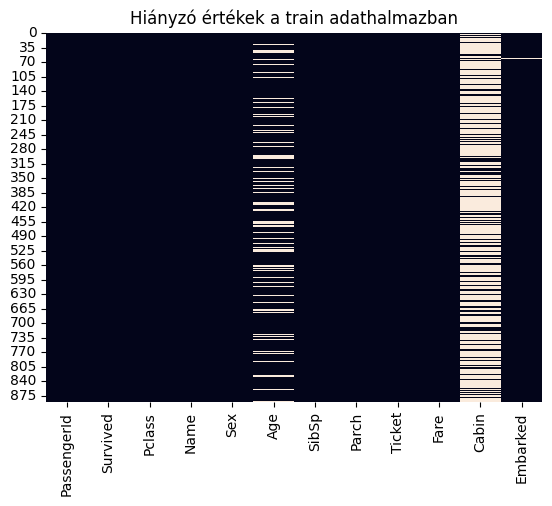

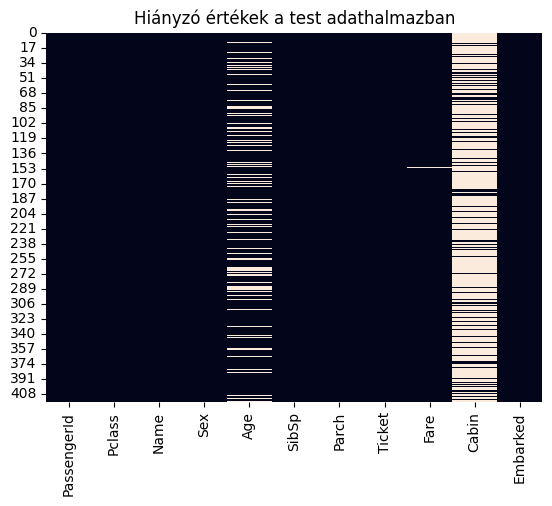

In [2394]:
sb.heatmap(train.isnull(), linecolor= "white", cbar=False)
plt.title('Hiányzó értékek a train adathalmazban')
plt.show()

sb.heatmap(test.isnull(), linecolor= "white", cbar=False)
plt.title('Hiányzó értékek a test adathalmazban')
plt.show()

In [2395]:
train_new = train.copy()

train_new['Age'] = train_new['Age'].fillna(train_new['Age'].median())

embarked_mode = train_new['Embarked'].mode()[0]
train_new['Embarked'] = train_new['Embarked'].fillna(embarked_mode)

train_new = train_new.drop(columns=['Cabin'])
train_new = train_new.drop(columns=['PassengerId'])
train_new = train_new.drop(columns=['Ticket'])

In [2396]:
test_new = test.copy()

test_new['Age'] = test_new['Age'].fillna(train_new['Age'].median())
test_new['Fare'] = test_new['Fare'].fillna(train_new['Fare'].median())

test_new['Embarked'] = test_new['Embarked'].fillna(embarked_mode)

test_new = test_new.drop(columns=['Cabin'])
test_new = test_new.drop(columns=['PassengerId'])
test_new = test_new.drop(columns=['Ticket'])

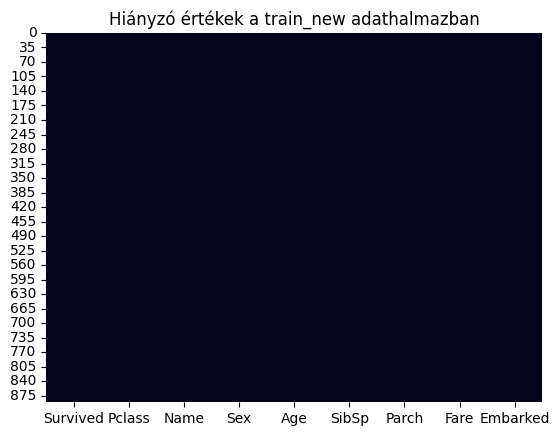

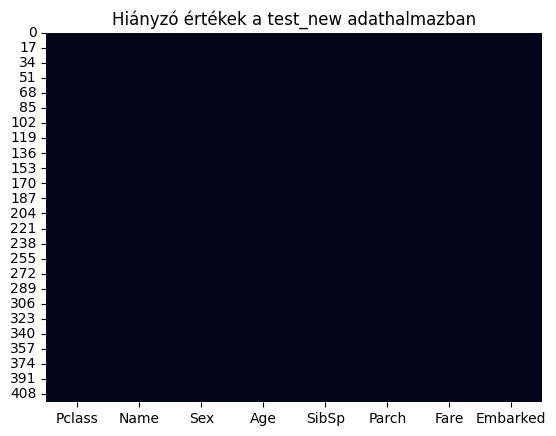

In [2397]:
sb.heatmap(train_new.isnull(), linecolor= "white", cbar=False)
plt.title('Hiányzó értékek a train_new adathalmazban')
plt.show()

sb.heatmap(test_new.isnull(), linecolor= "white", cbar=False)
plt.title('Hiányzó értékek a test_new adathalmazban')
plt.show()

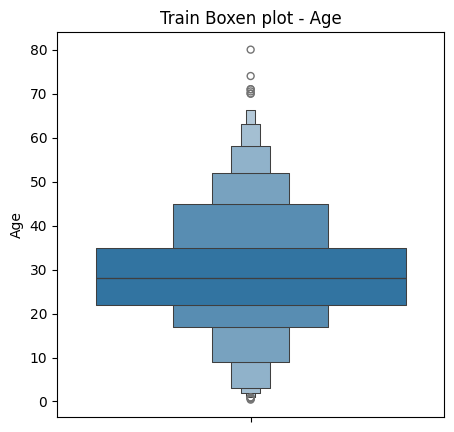

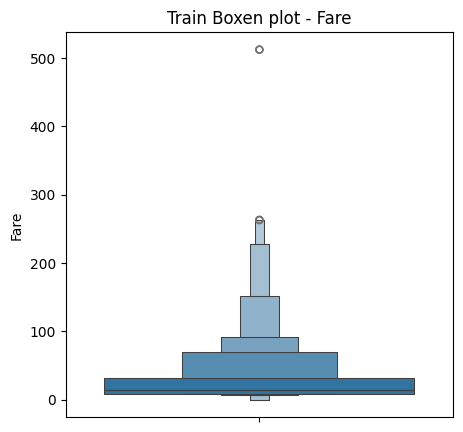

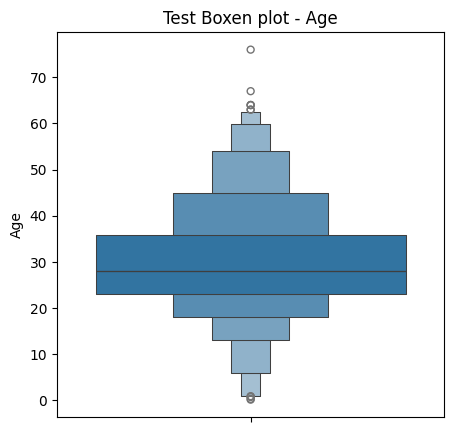

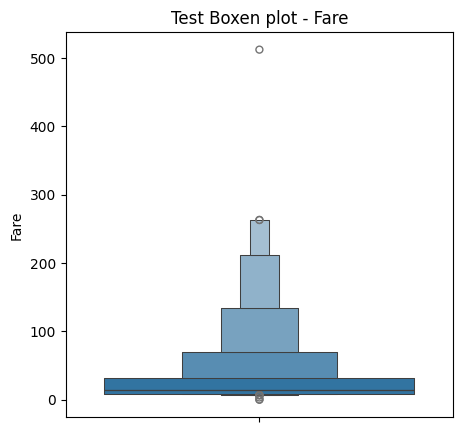

In [2398]:
for col in ['Age', 'Fare']:
    plt.figure(figsize=(5,5))
    sb.boxenplot(y=train_new[col])
    plt.title(f'Train Boxen plot - {col}')
    plt.show()

for col in ['Age', 'Fare']:
    plt.figure(figsize=(5,5))
    sb.boxenplot(y=test_new[col])
    plt.title(f'Test Boxen plot - {col}')
    plt.show()

## Feature engineering

In [2399]:
train_new['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test_new['FamilySize'] = train['SibSp'] + train['Parch'] + 1

In [2400]:
train_new['IsAlone'] = (train_new['FamilySize'] == 1).astype(int)
test_new['IsAlone'] = (test_new['FamilySize'] == 1).astype(int)

In [2401]:
train_new['Title'] = train_new['Name'].str.extract(r', (\w+)\.')[0]
test_new['Title'] = test_new['Name'].str.extract(r', (\w+)\.')[0]

title_counts = train_new['Title'].value_counts()
rare_titles = title_counts[title_counts < 30].index

train_new['Title'] = train_new['Title'].replace(rare_titles, 'Rare')
test_new['Title'] = test_new['Title'].replace(rare_titles, 'Rare')

train_new = pd.get_dummies(train_new, columns=['Title'], drop_first=False, dtype=int)
test_new = pd.get_dummies(test_new, columns=['Title'], drop_first=False, dtype=int)

train_new = train_new.drop(columns=['Name'])
test_new = test_new.drop(columns=['Name'])

In [2402]:
train_new = pd.get_dummies(train_new, columns=['Embarked'], drop_first=False, dtype=int)
test_new = pd.get_dummies(test_new, columns=['Embarked'], drop_first=False, dtype=int)

In [2403]:
train_new['Sex'] = train_new['Sex'].map({'male': 0, 'female': 1})
test_new['Sex'] = test_new['Sex'].map({'male': 0, 'female': 1})

In [2404]:
print(train_new.columns)
print(test_new.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'FamilySize', 'IsAlone', 'Title_Master', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Title_Rare', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')
Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'IsAlone', 'Title_Dona', 'Title_Master', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Title_Rare', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [2405]:
print(train_new.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  FamilySize  IsAlone  \
0         0       3    0  22.0      1      0   7.2500           2        0   
1         1       1    1  38.0      1      0  71.2833           2        0   
2         1       3    1  26.0      0      0   7.9250           1        1   
3         1       1    1  35.0      1      0  53.1000           2        0   
4         0       3    0  35.0      0      0   8.0500           1        1   

   Title_Master  Title_Miss  Title_Mr  Title_Mrs  Title_Rare  Embarked_C  \
0             0           0         1          0           0           0   
1             0           0         0          1           0           1   
2             0           1         0          0           0           0   
3             0           0         0          1           0           0   
4             0           0         1          0           0           0   

   Embarked_Q  Embarked_S  
0           0           1  
1           0     

## Standardizálás

In [2406]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
continuous_features = ['Age', 'Fare']

train_new[continuous_features] = scaler.fit_transform(train_new[continuous_features])
test_new[continuous_features] = scaler.transform(test_new[continuous_features])

In [2407]:
train_new.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,-0.565736,1,0,-0.502445,2,0,0,0,1,0,0,0,0,1
1,1,1,1,0.663861,1,0,0.786845,2,0,0,0,0,1,0,1,0,0
2,1,3,1,-0.258337,0,0,-0.488854,1,1,0,1,0,0,0,0,0,1
3,1,1,1,0.433312,1,0,0.420730,2,0,0,0,0,1,0,0,0,1
4,0,3,0,0.433312,0,0,-0.486337,1,1,0,0,1,0,0,0,0,1


## Adatok szétválasztása

In [2408]:
from sklearn.model_selection import train_test_split

In [2409]:
x_train = train_new.drop('Survived', axis=1)
y_train = train_new['Survived']

In [2410]:
x_train, x_validation, y_train, y_validation = train_test_split(
    x_train, y_train, test_size=0.1, random_state=22, stratify=y_train
)

In [2411]:
x_test = test_new.copy()

## Modell - Neurális háló

In [2412]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

In [2413]:
print(x_train.shape)
print(x_train.shape[1])

(801, 16)
16


In [2414]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

c:\Users\User\Desktop\X49HPQ_gepitanulas\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [2415]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4), 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

In [2416]:
model.summary()

Model: "sequential_67"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_265 (Dense)               │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_266 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_267 (Dense)               │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_268 (Dense)               │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 449 (1.75 KB)

 Trainable params: 449 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

In [2417]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True
)

In [2418]:
print(x_train.dtypes)

Pclass            int64
Sex               int64
Age             float64
SibSp             int64
Parch             int64
Fare            float64
FamilySize        int64
IsAlone           int64
Title_Master      int64
Title_Miss        int64
Title_Mr          int64
Title_Mrs         int64
Title_Rare        int64
Embarked_C        int64
Embarked_Q        int64
Embarked_S        int64
dtype: object


In [2419]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_validation, y_validation),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6467 - loss: 0.6528 - val_accuracy: 0.6556 - val_loss: 0.6431
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6404 - loss: 0.6310 - val_accuracy: 0.6778 - val_loss: 0.6213
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6442 - loss: 0.6138 - val_accuracy: 0.6778 - val_loss: 0.5997
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6642 - loss: 0.5976 - val_accuracy: 0.7000 - val_loss: 0.5806
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6767 - loss: 0.5855 - val_accuracy: 0.7000 - val_loss: 0.5683
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6891 - loss: 0.5745 - val_accuracy: 0.7000 - val_loss: 0.5571
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6916 - loss: 0.5644 - val_accuracy: 0.7222 - val_loss: 0.5464
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7041 - loss: 0.5547 - val_accuracy: 0.7444 - v

In [2420]:
loss, accuracy = model.evaluate(x_validation, y_validation, verbose=0)
print(f"Validation accuracy: {accuracy*100:.2f}%")

Validation accuracy: 85.56%


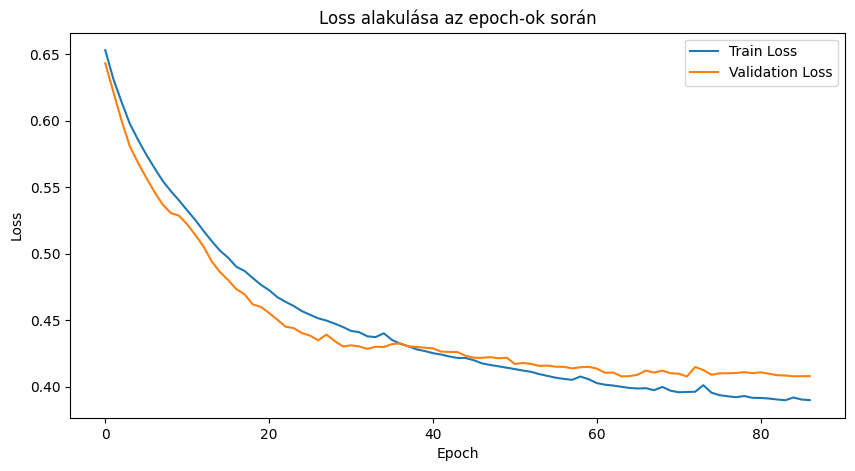

In [2421]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss alakulása az epoch-ok során')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

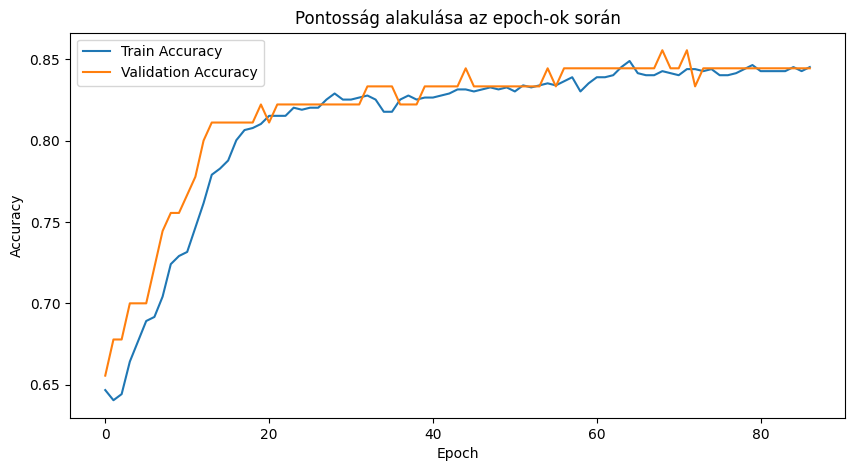

In [2422]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Pontosság alakulása az epoch-ok során')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [2423]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


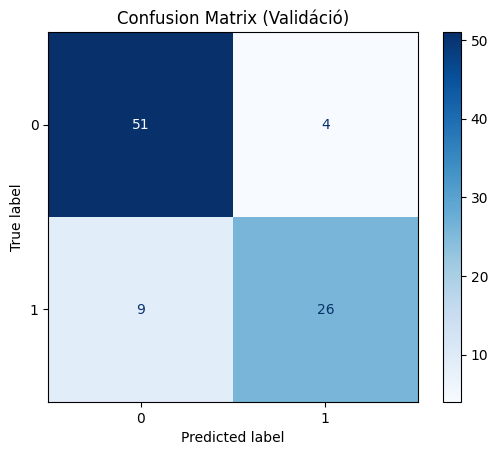

In [ ]:
y_validation_pred = (model.predict(x_validation) > 0.5).astype(int)

cm = confusion_matrix(y_validation, y_validation_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Validáció)")
plt.show()